In [1]:
# init
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 300}")

# BCS Fit

In [12]:
# get data
from superconductivity.evaluation import FileSpec

filespec = FileSpec(
    h5path="OI-25c-09 2025-05-02 unbroken stripline irradiation studies 0.hdf5",
    location="/Users/oliver/Documents/measurement data/25 04 OI-25c-09",
    measurement="vna_frequencies_0.100V",
)

# get keys
from superconductivity.evaluation import KeysSpec
from superconductivity.evaluation import get_keys

keysspec = KeysSpec(
    strip0="vna_",
    strip1="GHz_0.100V",
    remove_key="no_irradiation",
    add_key=[
        ("no_irradiation", 0.0),
    ],
    limits=(None, 0.01),
    norm=1,
    label="nu_GHz",
)

# get traces
from superconductivity.evaluation import TraceSpec
from superconductivity.evaluation import get_traces

tracespec = TraceSpec(
    AmpV=1000,
    AmpI=1000,
    trigger_values=1,
    skip_edges=5,
)

traces = get_traces(
    filespec=filespec,
    keysspec=keysspec,
    tracespec=tracespec,
)

# offset analysis
from superconductivity.evaluation import OffsetSpec
from superconductivity.evaluation import offset_analysis

offsetspec = OffsetSpec(
    Vbins_mV=np.linspace(-0.5, 0.5, 51),
    Ibins_nA=np.linspace(-5.0, 5.0, 51),
    Voffscan_mV=np.linspace(-0.045, 0.045, 451),
    Ioffscan_nA=np.linspace(-0.35, 0.35, 351),
    cutoff_Hz=43.7,
    sampling_Hz=137.0,
)

offsetanalysis = offset_analysis(
    traces=traces,
    spec=offsetspec,
)

# sampling
from superconductivity.evaluation import SamplingSpec
from superconductivity.evaluation import sample

samplingspec = SamplingSpec(
    Vbins_mV=np.linspace(-1.0, 1.0, 32001),
    Ibins_nA=np.linspace(-30.0, 30.0, 2001),
    Voff_mV=offsetanalysis.Voff_mV,
    Ioff_nA=offsetanalysis.Ioff_nA,
    cutoff_Hz=13.7,
    sampling_Hz=13700.0,
    median_bins=3,
    sigma_bins=40.0,
)

exp_v, exp_i = sample(
    traces=traces,
    samplingspec=samplingspec,
)

offset_analysis:   0%|          | 0/2 [00:00<?, ?trace/s]

sampling:   0%|          | 0/2 [00:00<?, ?trace/s]

In [13]:
Vbias0_mV = exp_v.V_mV
Iexp0_nA = exp_v.I_nA[0, :]
dV = Vbias0_mV[1] - Vbias0_mV[0]

model           ok    rmse_nA    GN_G0     T_K       Delta_meV  gamma_meV   sigmaV_mV
--------------  ----  ---------  --------  --------  ---------  ----------  ---------
bcs_conv_noise  True  0.0160935  0.189499  0.214972  0.1948     0.00112821  0.0103146


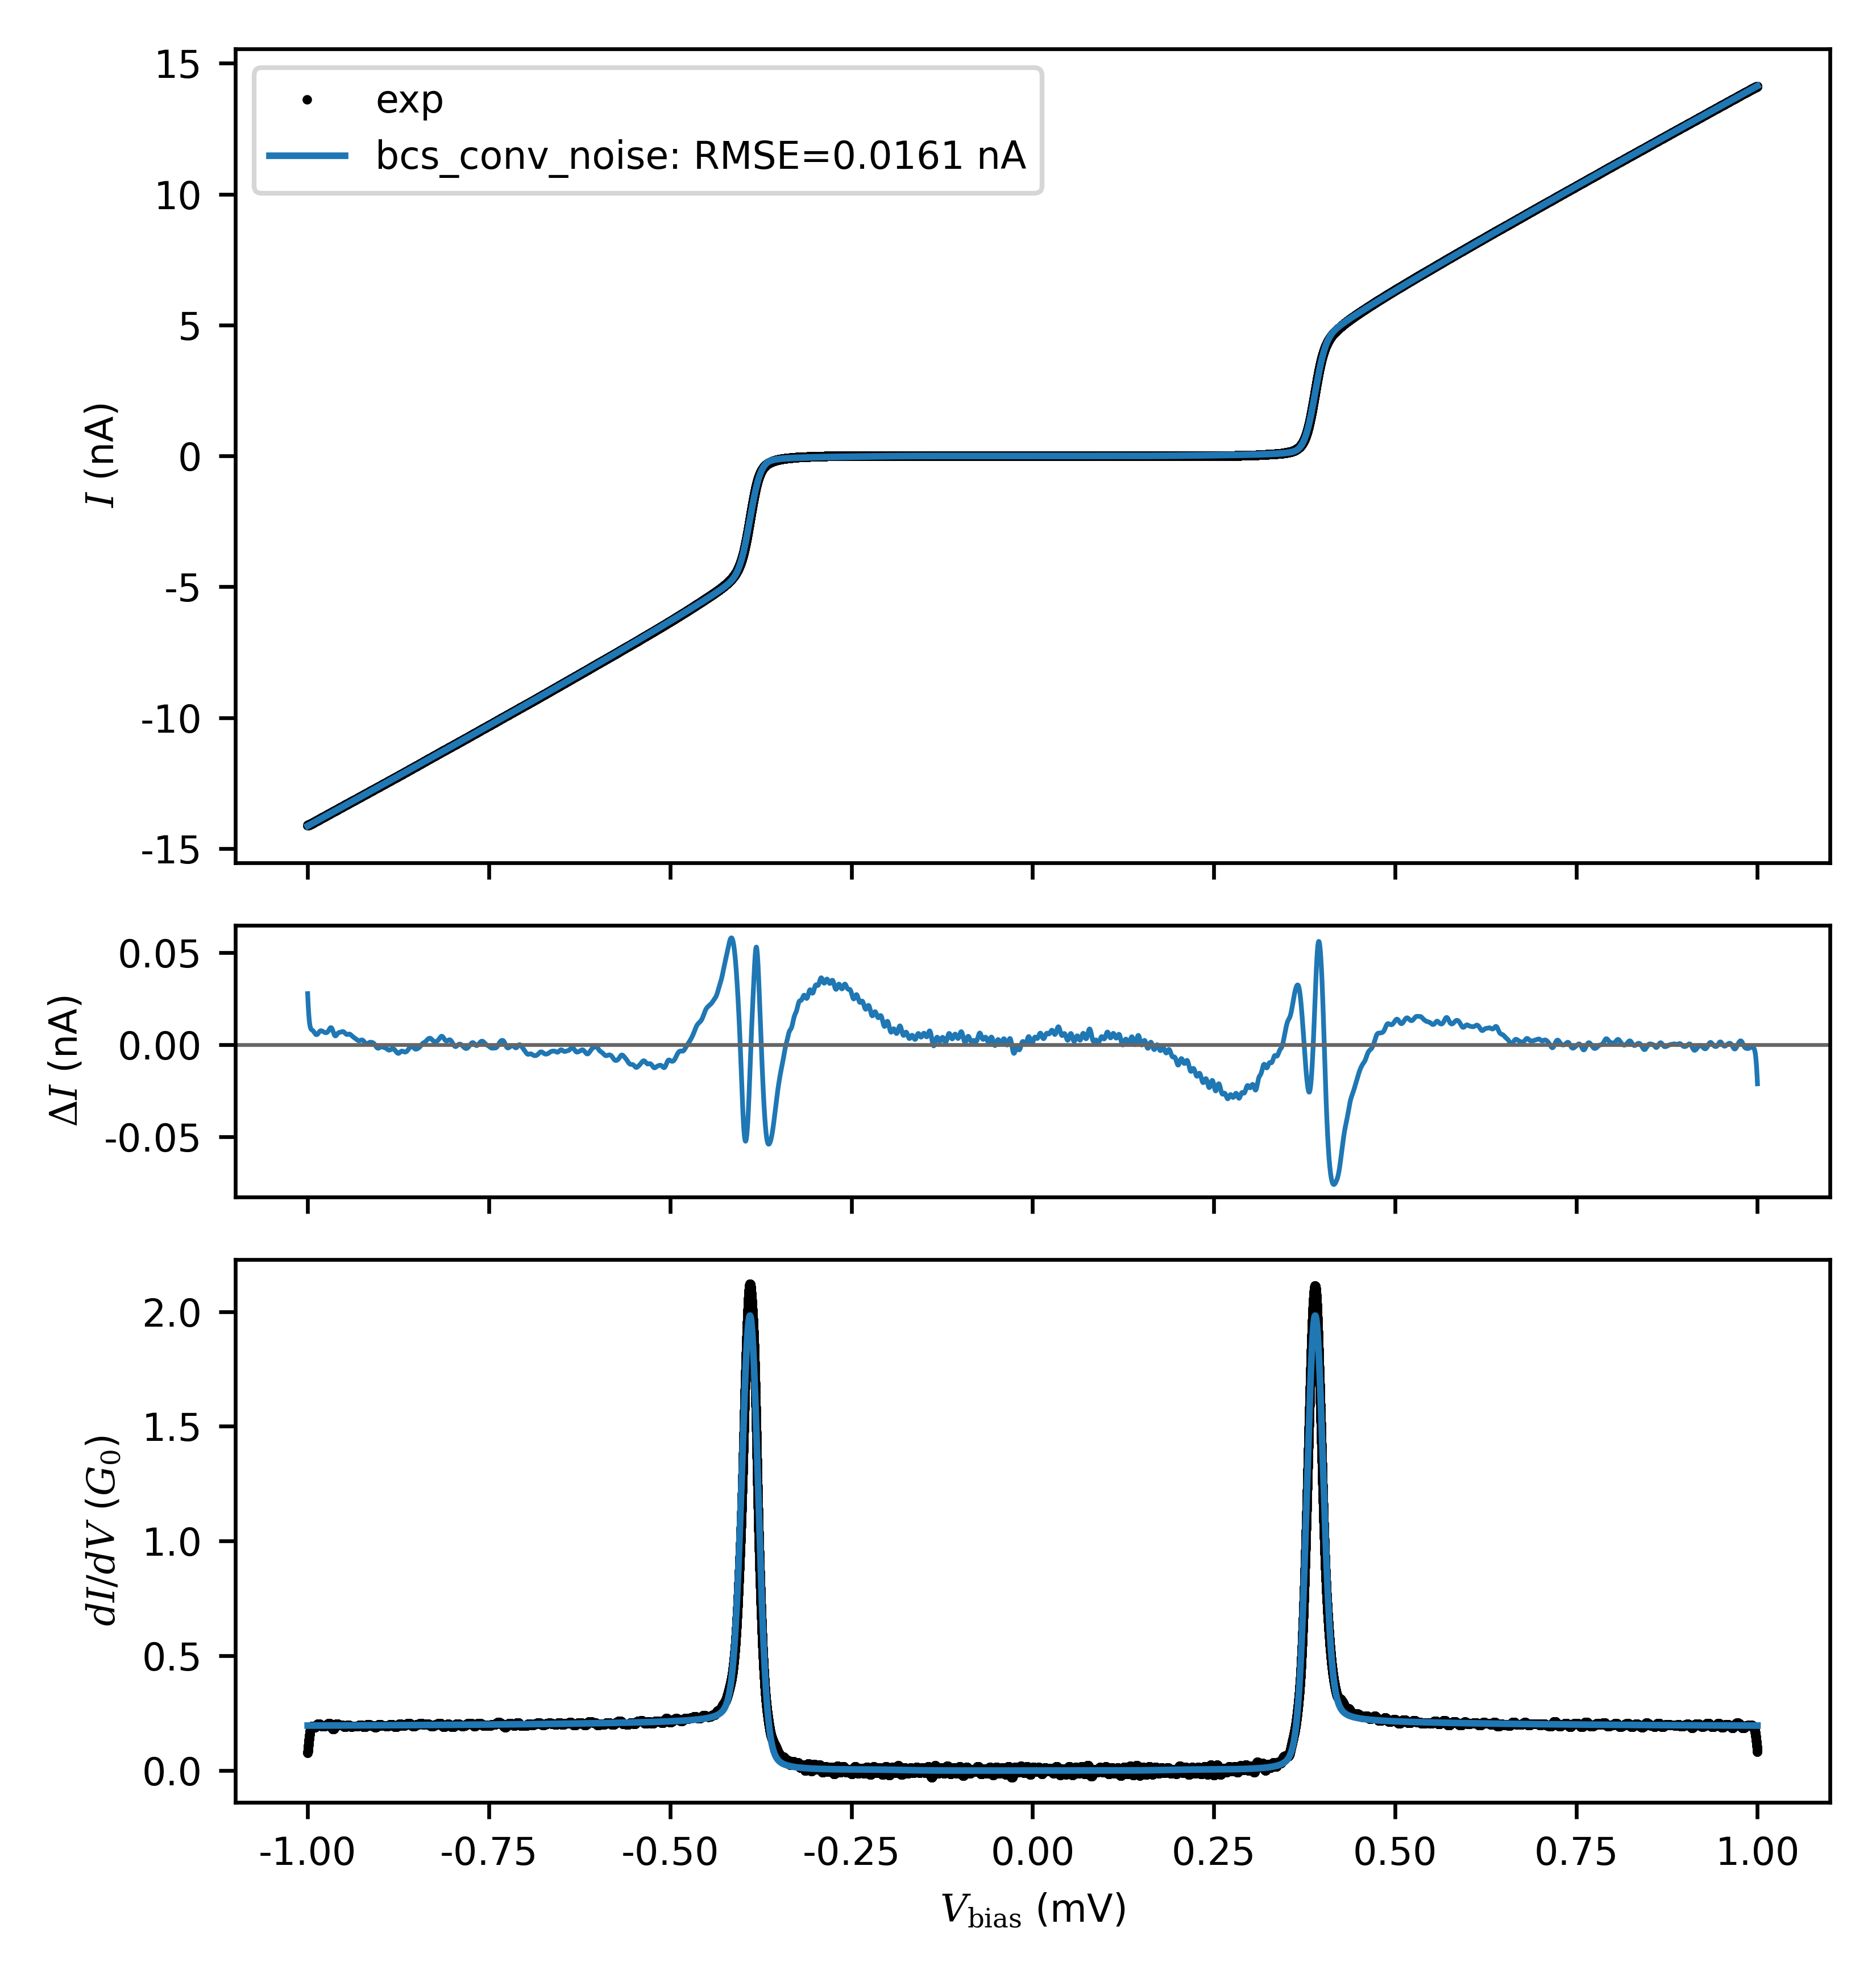

In [ ]:
settings = {
    "GN_G0": (0.189499, 0.1, 0.3, False),
    "T_K": (0.214949, 0.0, 1.2, False),
    "Delta_meV": (0.1948, 0.180, 0.210, False),
    "gamma_meV": (0.00112821, 1e-9, 25e-3, False),
    "sigmaV_mV": (0.0103146, 0.0, 1.0, False),
    "A_mV": (0.0, 0.0, 4.0, True),
    "nu_GHz": (0.0, 1.0, 20.0, True),
}

# fit only the noise-capable model
from bcs_fit import fit_bcs_conv_noise
from compare_bcs_fits import plot_bcs_conv_noise_fit, print_bcs_comparison_table

fit_row, noise_solution = fit_bcs_conv_noise(
    Vbias0_mV,
    Iexp0_nA,
    settings,
    maxfev=20_000,
)

print_bcs_comparison_table(
    [fit_row],
    columns=(
        "model",
        "ok",
        "rmse_nA",
        "GN_G0",
        "T_K",
        "Delta_meV",
        "gamma_meV",
        "sigmaV_mV",
    ),
)

Ifit_nA = noise_solution["I_fit_nA"]
fit_values = {parameter.name: parameter.value for parameter in noise_solution["params"]}
fit_errors = {parameter.name: parameter.error for parameter in noise_solution["params"]}

%matplotlib inline
fig = plot_bcs_conv_noise_fit(fit_row, noise_solution)